# 회귀
- X와 Y 사이의 "관계"를 수식(H(X))으로 표현한다
- 그 수식이 예측하는 값(Ŷ)이 실제값(Y)과 최대한 비슷해지도록 만든다
- 수식의 형태(직선/곡선 등)는 사람이 고르고, 그 안의 가중치는 자동으로 학습된다

In [ ]:
import numpy as np

original_X = [1,2,3,4,5]
original_Y = [2.1,4.3,5.8,7.8,10.1]

X = np.array(original_X)
Y = np.array(original_Y)

# -1: 해당 차원을 알아서 계산해주세요.
# scikit-learn 등 머신러닝 라이브러리는 입력 X를 (n_samples, n_features) 형태의
# 2차원 배열로 기대하기 때문에, 특성이 1개뿐이어도 column 벡터 형태로 맞춰줘야 한다.
X = X.reshape(-1, 1)
Y = Y.reshape(-1, 1)

print(X)
print(Y)

[[1]
 [2]
 [3]
 [4]
 [5]]
[[ 2.1]
 [ 4.3]
 [ 5.8]
 [ 7.8]
 [10.1]]


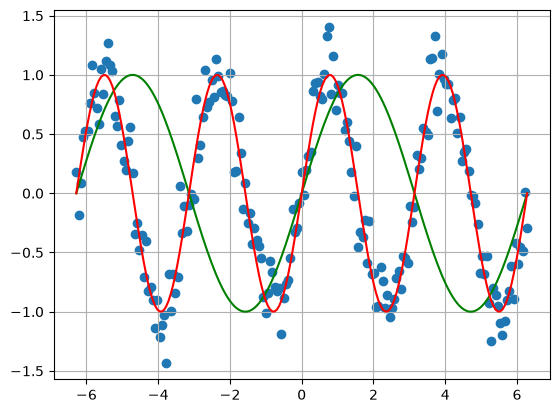

In [ ]:
# 모델 정하기
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-2*np.pi, 2*np.pi, 201)

feature_data = x
label_data = np.sin(2*x)+ np.random.normal(0,0.2,x.size)
model = np.sin(feature_data)
model2 = np.sin(feature_data * 2)

plt.grid()
# label 데이터의 분포
plt.scatter(feature_data, label_data)
# label 데이터를 잘 따라가지 못하는 모델
plt.plot(feature_data, model, 'g')
# label 데이터를 잘 따라가는 모델
plt.plot(feature_data, model2, 'r')

In [2]:
# 오류(error)
import numpy as np

feature_data = np.array([1, 2, 3, 4]).reshape(-1, 1)
label_data = np.array([3.1, 4.9, 7.2, 8.9]).reshape(-1, 1)

f_x = 2 * feature_data + 1

error = label_data - f_x

# print(label_data)
# print(f_x)
# print(error)

model1 = 3 * feature_data
model2 = feature_data ** 2 + 1
model3 = np.exp(feature_data)
models = [model1, model2, model3]

[print(label_data - m) for m in models]

[[ 0.1]
 [-1.1]
 [-1.8]
 [-3.1]]
[[ 1.1]
 [-0.1]
 [-2.8]
 [-8.1]]
[[  0.38171817]
 [ -2.4890561 ]
 [-12.88553692]
 [-45.69815003]]


[None, None, None]

In [ ]:
import numpy as np

# Loss 측정(MSE)으로 좋은 모델 판단하기
# loss값이 작을수록 적합한 모델
def loss(f_x, label_data):
  error = label_data - f_x
  ls = np.mean(error ** 2)
  return ls

print(loss(f_x, label_data))
print(loss(model1, label_data))
print(loss(model2, label_data))
print(loss(model3, label_data))

0.017499999999999988
3.517499999999999
18.6675
565.1747718191755


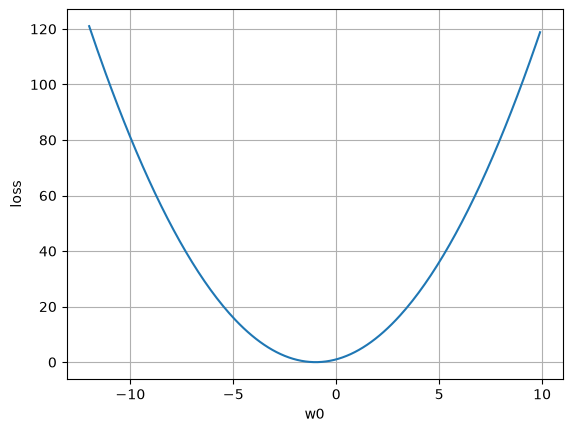

In [ ]:
# loss 구하기
import numpy as np
import matplotlib.pyplot as plt

w0 = np.arange(-12, 10, 0.1)

# MSE 계산(손실을 구하는 방법)으로 손실함수를 나타날 시 feature와 label의 쌍이 정해져 있다고 가정하면 w0(가중치)가 2차 함수꼴로 나타나며
# 손실이 가장 낮을 때가 가중치가 최적일 때이므로 기울기가 0인 것이 곧 최솟값이므로 그 지점의 w0이 최적의 가중치이다.
# 예시: feature/label 3쌍 (x1,y1), (x2,y2), (x3,y3)이 주어지고 w1이 고정되어 있다면,
#       Loss(w0) = (1/3) * [(y1-(w0+w1*x1))^2 + (y2-(w0+w1*x2))^2 + (y3-(w0+w1*x3))^2]
#       이를 전개하면 Loss(w0) = A*w0^2 + B*w0 + C 형태의 2차함수(포물선)가 되고,
#       이 포물선의 최저점(기울기=0)이 바로 최적의 w0이다.
loss_w0 = 1 * w0 ** 2 + 2 * w0 + 1

plt.plot(w0, loss_w0)
plt.xlabel('w0')
plt.ylabel('loss')
plt.grid()

In [ ]:
# sklearn: 다양한 머신러닝 기법을 쉽게 사용할 수 있는 라이브러리
from sklearn.linear_model import LinearRegression

# 모델 설정(선형 회귀 모델)
sci_model = LinearRegression()

# 학습 수행(지도학습 방식으로 여러 가중치를 동시에 최적화)
sci_model.fit(feature_data, label_data)

# sklearn에는 제대로 학습했는지에 대한 손실 함수가 없기 때문에 직접 정의
print(loss(sci_model.predict(feature_data), label_data))

# RMSE: MSE의 제곱근으로, 오차를 원래 데이터와 같은 단위로 되돌려서 사람이 직관적으로 이해하기 쉽게 만든 지표
def RMSE(predicted_data, label_data):
  error = predicted_data - label_data
  ls = np.sqrt(np.mean(error ** 2))
  return ls

# R2: label의 평균만 반환하는 모델의 오차 제곱 합을 분모로 삼아 그 비율을 기준으로 모델이 얼마나 오차를 줄일 수 있는가를 판단할 수 있음
def R2(predicted_data, label_data):
  r2 = 1 - (np.sum((label_data - predicted_data) ** 2) / np.sum((label_data - np.mean(label_data)) ** 2))
  return r2


print(RMSE(sci_model.predict(feature_data), label_data))
print(R2(sci_model.predict(feature_data), label_data))

0.015749999999999945
0.1254990039801111
0.996763837164505


In [ ]:
# 경사하강법: 현재 위치에서 가장 가파르게 내려가는 방향(gradient)으로 조금씩 반복 이동하며 여러 가중치를 한 번에 최적화하는 방법
import numpy as np

def gradient(w0, w1, feature_X, label_Y):
    
  gradient_w0 = -2/(feature_X.size) * np.sum(label_Y - (w0+w1*feature_X))
  gradient_w1 = -2/(feature_X.size) * np.sum((label_Y - (w0+w1*feature_X))*(feature_X))
  
  return np.array([gradient_w0, gradient_w1])

feature_data = np.array([1,2,3,4]).reshape((-1,1))
label_data = np.array([3.1, 4.9, 7.2, 8.9]).reshape((-1,1))

gradient(1,1,feature_data,label_data)

# 파라미터 초기화
w0 = 0
w1 = 0

# learning rate 설정
lr = 0.001

# 1차 선형 모델 함수 정의
def linear_model(w_0, w_1, feature_data):
  f_x = w_0 + w_1*feature_data
  return f_x

# loss 함수 정의
def loss(f_x, label_data):
  error = label_data - f_x
  ls = np.mean(error**2)
  return ls

# 반복 횟수 1000으로 설정

for i in range(1000):
  gd = gradient(w0,w1,feature_data,label_data)
  w0 = w0 - lr*gd[0]
  w1 = w1 - lr*gd[1]
    
  if (i%100 == 0):
    print("loss : {}".format(loss(linear_model(w0,w1,feature_data),label_data)))
    print("w0, w1 : {}, {}".format(w0,w1))

loss : 39.80526573375
w0, w1 : 0.012050000000000002, 0.03505
loss : 1.4088818550020328
w0, w1 : 0.5956839328965645, 1.7137245928510965
loss : 0.08492622860667261
w0, w1 : 0.7129266308916146, 2.0222518370363343
loss : 0.03808809478420731
w0, w1 : 0.7433441610180002, 2.0765698140220747
loss : 0.03531467697283942
w0, w1 : 0.7573915882750667, 2.0837935212742202
loss : 0.03412659366543372
w0, w1 : 0.7681528769083021, 2.0823608526346415
loss : 0.033056629416450725
w0, w1 : 0.7780637167868475, 2.079403378165377
loss : 0.032050551054706465
w0, w1 : 0.787583266851497, 2.0762423007849082
loss : 0.031103013292289844
w0, w1 : 0.7968036334081118, 2.0731204929145344
loss : 0.030210557013104773
w0, w1 : 0.8057485947959019, 2.070080758386106


In [ ]:
# 규제: 오차를 줄이는 것뿐 아니라 가중치 크기에도 벌점을 줘서, 모델이 노이즈까지 과하게 학습하지(과적합) 않도록 억제하는 기법
# learning_rate가 작으면 최적화까지 오래 걸리고, 크면 최솟값을 지나쳐 발산할 수 있어서 학습 중 적절히 조절해야 하고
# 초기값이 최솟값과 너무 떨어져 있으면 학습이 오래 걸릴 수 있는데,
# 이 두 문제(learning rate 자동조절, 초기값 자동설정) 모두 이를 해결해주는 라이브러리 기능이 존재함

In [ ]:
# 다중 선형 회귀
import numpy as np

# transpose: 전치 (2, 4) -> (4, 2)
X_feature = np.array([[1, 2, 3, 4], [3, 6, 7, 8]]).transpose()
Y = np.array([3.1, 4.9, 7.2, 8.9]).reshape(-1, 1)

# w0 + w1*x1 + w2*x2 + ...와 같은 형태를 행렬곱으로 나타내야 하는데 열 하나를 추가하지 않으면 w0의 상수항 가중치는 사라진다(정확도 감소).
X_feature = np.concat((np.ones((4, 1), dtype=int), X_feature), axis=1)
print(X_feature)

# 파라미터 column 설정
w = np.random.randint(1, 10, size=3).reshape(-1, 1)
print(w)

# 다중 선형 모델 생성
def F_X (w, X):
  return X @ w

def loss(f_x, label_data):
  error = label_data - f_x
  return np.mean(error ** 2)

prediction = F_X(w, X_feature)

print(loss(prediction, Y))

[[1 1 3]
 [1 2 6]
 [1 3 7]
 [1 4 8]]
[[9]
 [2]
 [3]]
706.6675
